<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()

X = iris.data
y = iris.target

# Dividindo em dados de treino e dados de teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Tamanho de X_train:", X_train.shape)
print("Tamanho de X_test:", X_test.shape)
print("Tamanho de y_train:", y_train.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de X_train: (105, 4)
Tamanho de X_test: (45, 4)
Tamanho de y_train: (105,)
Tamanho de y_test: (45,)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cria o modelo
modelo = DecisionTreeClassifier(max_depth = 3, random_state=42)

# Treina o modelo
modelo.fit(X_train, y_train)

# Faz previsões
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Calcula as acurácias
acuracia_treino = accuracy_score(y_train, y_pred_train)
acuracia_teste = accuracy_score(y_test, y_pred_test)

print("Acurácia no treino:", acuracia_treino)
print("Acurácia no teste:", acuracia_teste)

Acurácia no treino: 0.9809523809523809
Acurácia no teste: 0.9777777777777777


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

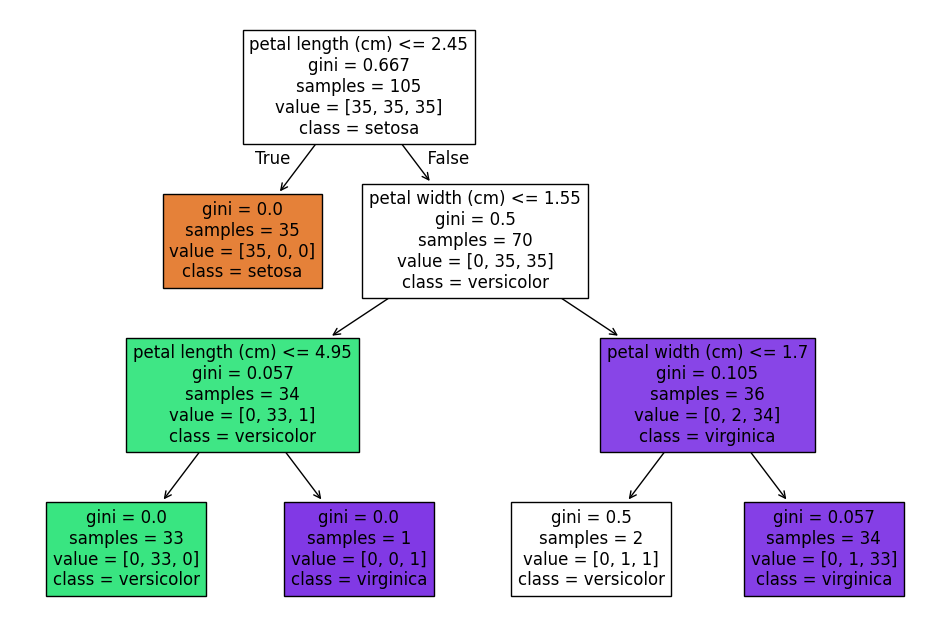

In [3]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

O atributo presente na raiz da árvore é petal length (cm), que é a primeira variável utilizada para dividir os dados.

A profundidade da árvore é 3, considerando o maior número de divisões entre a raiz e os nós folha e de acordo com a profundidade estabelecida no atributo max_depth.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [5]:
import pandas as pd

resultados = []

for profundidade in [1, 2, 3, 4, 5, 6, 7, 8, 9, None]:
    modelo = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    resultados.append({
        "max_depth": profundidade,
        "acurácia_treino": accuracy_score(y_train, y_pred_train),
        "acurácia_teste": accuracy_score(y_test, y_pred_test),
        "profundidade_arvore": modelo.get_depth(),
        "numero_folhas": modelo.get_n_leaves()
    })

tabela = pd.DataFrame(resultados)
print(tabela)

   max_depth  acurácia_treino  acurácia_teste  profundidade_arvore  \
0        1.0         0.666667        0.666667                    1   
1        2.0         0.971429        0.888889                    2   
2        3.0         0.980952        0.977778                    3   
3        4.0         0.990476        0.888889                    4   
4        5.0         1.000000        0.933333                    5   
5        6.0         1.000000        0.933333                    5   
6        7.0         1.000000        0.933333                    5   
7        8.0         1.000000        0.933333                    5   
8        9.0         1.000000        0.933333                    5   
9        NaN         1.000000        0.933333                    5   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              8  
5              8  
6              8  
7              8  
8              8  
9              8  


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa aproximadamente em max_depth = 4, pois a partir desse ponto a acurácia no treino continua aumentando enquanto a acurácia no teste diminui em relação ao melhor resultado obtido com profundidade 3.

Quando max_depth=None, a árvore de decisão não possui limite de profundidade. Dessa forma, o modelo continua criando divisões até classificar perfeitamente todos os exemplos do conjunto de treino, o que pode levar ao fenômeno de overfitting, no qual o modelo memoriza os dados de treinamento em vez de aprender padrões generalizáveis.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [6]:
# Modelo usando Gini
modelo_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
modelo_gini.fit(X_train, y_train)

y_pred_gini = modelo_gini.predict(X_test)

# Modelo usando Entropy
modelo_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
modelo_entropy.fit(X_train, y_train)

y_pred_entropy = modelo_entropy.predict(X_test)

# Resultados
print("Modelo Gini")
print("Acurácia:", accuracy_score(y_test, y_pred_gini))
print("Profundidade:", modelo_gini.get_depth())

print("\nModelo Entropy")
print("Acurácia:", accuracy_score(y_test, y_pred_entropy))
print("Profundidade:", modelo_entropy.get_depth())

Modelo Gini
Acurácia: 0.9333333333333333
Profundidade: 5

Modelo Entropy
Acurácia: 0.8888888888888888
Profundidade: 6


Foram treinados dois modelos de árvore de decisão, um com o critério gini e outro com entropy. O modelo com gini apresentou acurácia de 93,33% e profundidade 5, enquanto o modelo com entropy apresentou acurácia de 88,89% e profundidade 6. Assim, para essa divisão de treino e teste, o critério gini apresentou melhor desempenho, pois obteve maior acurácia com uma árvore menos profunda.

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [7]:
melhor_modelo = None
melhor_acuracia = 0
melhor_profundidade = None

for profundidade in range(1,10):
    
    modelo = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if acc > melhor_acuracia:
        melhor_acuracia = acc
        melhor_modelo = modelo
        melhor_profundidade = profundidade

print("Melhor modelo encontrado")
print("max_depth:", melhor_profundidade)
print("Acurácia:", melhor_acuracia)

Melhor modelo encontrado
max_depth: 3
Acurácia: 0.9777777777777777


Foi investigado o hiperparâmetro max_depth, que controla a profundidade máxima da árvore de decisão. Foram treinados modelos com diferentes valores desse parâmetro e comparadas suas acurácias no conjunto de teste. O melhor modelo encontrado utilizou max_depth = 3, alcançando acurácia de aproximadamente 97,78%. Profundidades maiores aumentaram a complexidade da árvore sem melhorar o desempenho, indicando possível início de overfitting. Portanto, o modelo com max_depth = 3 apresentou o melhor equilíbrio entre simplicidade e desempenho

In [8]:
for leaf in [1,2,3,4,5,6,7,8,9,10]:

    modelo = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    print(
        "min_samples_leaf:", leaf,
        "| acurácia:", accuracy_score(y_test, y_pred),
        "| profundidade:", modelo.get_depth(),
        "| folhas:", modelo.get_n_leaves()
    )

min_samples_leaf: 1 | acurácia: 0.9333333333333333 | profundidade: 5 | folhas: 8
min_samples_leaf: 2 | acurácia: 0.8888888888888888 | profundidade: 4 | folhas: 6
min_samples_leaf: 3 | acurácia: 0.8444444444444444 | profundidade: 4 | folhas: 6
min_samples_leaf: 4 | acurácia: 0.8888888888888888 | profundidade: 4 | folhas: 6
min_samples_leaf: 5 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5
min_samples_leaf: 6 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5
min_samples_leaf: 7 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5
min_samples_leaf: 8 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5
min_samples_leaf: 9 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5
min_samples_leaf: 10 | acurácia: 0.8888888888888888 | profundidade: 3 | folhas: 5


Também foi investigado o hiperparâmetro min_samples_leaf, que define o número mínimo de amostras em cada folha da árvore de decisão. Observou-se que valores maiores desse parâmetro reduzem a profundidade da árvore e o número de folhas, tornando o modelo mais simples. Nos experimentos realizados, o melhor desempenho foi obtido com min_samples_leaf = 1, alcançando acurácia de aproximadamente 93,33% no conjunto de teste. Valores maiores reduziram a complexidade da árvore, mas também diminuíram o desempenho do modelo.